# 3.2 Download the Sample Dataset

In [1]:
from datasets import load_dataset
import json

# Load the C4 dataset in streaming mode
ds = load_dataset('allenai/c4', 'en', split='validation', streaming=True)

# Take 2000 samples from the dataset
samples = list(ds.take(2000))

# Save samples to a JSONL file
with open('sample_web_text.jsonl', 'w') as f:
    for item in samples:
        f.write(json.dumps({
            'text': item['text'],
            'url': item['url']
        }) + '\n')

print(f'Saved {len(samples)} documents to sample_web_text.jsonl')

/Users/tsheringwangpodorji/Documents/Year3 Sem II/DAM304/practical_1/practical1-env/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Saved 2000 documents to sample_web_text.jsonl


# 4. Practical Tasks

## Task 1 — Data Loading & Baseline Statistics

In [4]:
import json
from langdetect import detect, LangDetectException
from collections import Counter

# ---------- Load dataset ----------
def load_jsonl(path):
    """Load documents from a JSONL file."""
    docs = []
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            docs.append(json.loads(line.strip()))
    return docs

docs = load_jsonl('sample_web_text.jsonl')
print(f'Loaded {len(docs)} documents')

# Create a tracking dictionary for pipeline stages
pipeline_counts = {}

# ---------- Compute statistics ----------
def get_stats(docs):
    """Compute statistics about the documents."""
    lengths_chars = [len(d['text']) for d in docs]
    lengths_words = [len(d['text'].split()) for d in docs]
    
    langs = []
    for d in docs:
        try:
            langs.append(detect(d['text'][:500]))
        except LangDetectException:
            langs.append('unknown')
    
    return {
        'n_docs': len(docs),
        'total_chars': sum(lengths_chars),
        'avg_chars': sum(lengths_chars) / len(docs),
        'avg_words': sum(lengths_words) / len(docs),
        'min_chars': min(lengths_chars),
        'max_chars': max(lengths_chars),
        'lang_dist': Counter(langs).most_common(10),
    }

baseline = get_stats(docs)
print(baseline)

Loaded 2000 documents
{'n_docs': 2000, 'total_chars': 4209414, 'avg_chars': 2104.707, 'avg_words': 354.6575, 'min_chars': 58, 'max_chars': 57460, 'lang_dist': [('en', 1995), ('el', 1), ('de', 1), ('id', 1), ('sv', 1), ('et', 1)]}


#### Output Explanation 

There is a **total of 2000 documents** with **total characters** of **4209414** and an **average of 2104.707 characters per document**. The **average number of words per document is 354.6575**, with a **minimum of 58 characters** and a **maximum of 57460 characters**. The language distribution shows that the majority of documents are in English (1995), with a few documents in other languages such as Greek (1), German (1), Indonesian (1), Swedish (1), and Estonian (1).

## Task 2 — Heuristic Filtering & Text Normalisation

### Step 2a — Language Filter

In [5]:
from langdetect import detect, LangDetectException

def filter_english(docs):
    """
    Return only documents whose language is detected as English.
    Discard documents with undetermined language.
    """
    english_docs = []
    for d in docs:
        try:
            # Detect language using first 500 characters
            lang = detect(d['text'][:500])
            if lang == 'en':
                english_docs.append(d)
        except LangDetectException:
            # Skip documents with undetermined language
            pass
    return english_docs

docs = filter_english(docs)
pipeline_counts['after_language'] = len(docs) 
print(f'After language filter: {len(docs)} docs')

After language filter: 1994 docs


#### Output Explanation 

In this section we apply a language filter meaning obtaining only the english documents. After filtering, we have **1994 English documents** remaining in the dataset. 

### Step 2b — Length Filter 

In [6]:
def filter_length(docs, min_words=50, max_words=100000):
    """
    Return only documents whose word count is between min_words and max_words.
    Word count = number of whitespace-separated tokens in the text.
    """
    filtered_docs = []
    for d in docs:
        word_count = len(d['text'].split())
        if min_words <= word_count <= max_words:
            filtered_docs.append(d)
    return filtered_docs

docs = filter_length(docs)
pipeline_counts['after_length'] = len(docs)
print(f'After length filter: {len(docs)} docs')

After length filter: 1780 docs


#### Output Explanation 

After Length filtering, the number of documents is reduced to **1780** from the original 1994 English documents that has been obtained after applying the language filter.

### Step 2c — Symbol Ratio Filter 

In [7]:
def filter_symbol_ratio(docs, max_ratio=0.30):
    """
    Return only documents where the non-alphabetic character ratio is <= max_ratio. 
    ratio = (len(text) - alphabetic_count) / len(text) 
    """
    filtered_docs = []
    for d in docs:
        text = d['text']
        if len(text) > 0:
            alphabetic_count = sum(c.isalpha() for c in text)
            ratio = (len(text) - alphabetic_count) / len(text)
            if ratio <= max_ratio:
                filtered_docs.append(d)
    return filtered_docs
    
docs = filter_symbol_ratio(docs)
pipeline_counts['after_symbol'] = len(docs)
print(f'After symbol filter: {len(docs)} docs')

After symbol filter: 1759 docs


#### Output Explanation 
The symbol ratio filter further reduces the number of documents to **1759**. This means that 31 documents were removed due to having a high ratio of non-alphabetic characters, which could indicate noise or irrelevant content in those documents.

### Step 2d — Text Normalisation 

In [8]:
import re
import ftfy
from bs4 import BeautifulSoup

def normalise_text(text):
    # Fix encoding errors such as mojibake and incorrect quote characters
    text = ftfy.fix_text(text)
    # Remove any residual HTML tags
    text = BeautifulSoup(text, 'html.parser').get_text(separator=' ')
    # Collapse multiple whitespace characters into a single space
    text = re.sub(r'\s+', ' ', text).strip()
    # Remove null bytes and ASCII control characters
    text = re.sub(r'[\x00-\x08\x0b\x0c\x0e-\x1f]', '', text)
    return text

# Save a sample before normalization for observation
sample_before = docs[0]['text'][:300] if docs else ""

for d in docs:
    d['text'] = normalise_text(d['text'])

print('Normalisation complete')

# Show example of normalization (for observation)
sample_after = docs[0]['text'][:300] if docs else ""
print(f'\nExample - Before normalization:\n{sample_before}\n')
print(f'Example - After normalization:\n{sample_after}')

Normalisation complete

Example - Before normalization:
The woman who died after falling from a bridge over the A21 has been identified as a Sevenoaks mum.
Marta Kendle, 37, fell from the Gracious Lane bridge on the morning of February 19.
Police were called to the carriageway around 6.10am and the road was promptly closed in both directions.
Despite par

Example - After normalization:
The woman who died after falling from a bridge over the A21 has been identified as a Sevenoaks mum. Marta Kendle, 37, fell from the Gracious Lane bridge on the morning of February 19. Police were called to the carriageway around 6.10am and the road was promptly closed in both directions. Despite par


## Task 3 — Near-Deduplication with MinHash

### Step 3a — Shingling Function 

In [9]:
def get_shingles(text, k=5):
    """
    Return the set of all overlapping character k-grams in text.
    Lowercase text before shingling.
    Example: get_shingles('Hello', k=3) -> {'hel', 'ell', 'llo'}
    """
    text = text.lower()
    shingles = set()
    for i in range(len(text) - k + 1):
        shingles.add(text[i:i+k])
    return shingles

# Test the function
test_shingles = get_shingles('Hello', k=3)
print(f'Test shingles for "Hello": {test_shingles}')

Test shingles for "Hello": {'ell', 'llo', 'hel'}


#### Output Explanation 

Shingling is a technique used to represent documents as a unique set. 
Example given that; "The sky is blue and the sun is bright" with K=3 3 shingling in word,
- "The sky is"
- "sky is blue"     
- "is blue and"
- "blue and the"
- "and the sun"
- "the sun is"
- "sun is bright"

#### Output Explanation

The shingling function returns a set of overlapping characters with K=3.


### Step 3b — MinHash Deduplication Pipeline 

In [10]:
from datasketch import MinHash, MinHashLSH
import copy

def minhash_dedup(docs, threshold=0.80, num_perm=128):
    """
    Remove near-duplicate documents using MinHash LSH.
    threshold: Jaccard similarity above which two docs are considered duplicates.
    num_perm: Number of hash functions. Higher value = more accurate estimate.
    """
    lsh = MinHashLSH(threshold=threshold, num_perm=num_perm)
    minhashes = {}
    
    # Build a MinHash signature for every document
    for i, d in enumerate(docs):
        m = MinHash(num_perm=num_perm)
        for shingle in get_shingles(d['text']):
            m.update(shingle.encode('utf-8'))
        minhashes[i] = m
    
    # Insert into LSH index, skipping documents similar to ones already inserted
    unique_ids = set()
    for i, m in minhashes.items():
        result = lsh.query(m)
        if not result:
            lsh.insert(str(i), m)
            unique_ids.add(i)
    
    return [docs[i] for i in sorted(unique_ids)]

# Save a backup before deduplication for the threshold experiment below
docs_backup = copy.deepcopy(docs)

docs = minhash_dedup(docs, threshold=0.80)
pipeline_counts['after_dedup'] = len(docs)
print(f'After deduplication: {len(docs)} docs')

After deduplication: 1758 docs


### Step 3c — Threshold Experiment [YOUR TASK]

In [11]:
# Run minhash_dedup with different thresholds
thresholds = [0.70, 0.80, 0.90]
threshold_results = {}

print("\n=== THRESHOLD EXPERIMENT ===")
for threshold in thresholds:
    # Use deepcopy to preserve the backup
    docs_test = copy.deepcopy(docs_backup)
    docs_test = minhash_dedup(docs_test, threshold=threshold)
    threshold_results[threshold] = len(docs_test)
    print(f'Threshold {threshold}: {len(docs_test)} docs remaining')


=== THRESHOLD EXPERIMENT ===
Threshold 0.7: 1758 docs remaining
Threshold 0.8: 1758 docs remaining
Threshold 0.9: 1758 docs remaining


## Task 4 — Final Statistics & Pipeline Summary

In [12]:
# Compute final statistics
final = get_stats(docs)

print('\n=== FINAL STATISTICS ===')
print(f"Final document count: {final['n_docs']}")
print(f"Average characters: {final['avg_chars']:.0f}")
print(f"Average words: {final['avg_words']:.0f}")
print(f"Min characters: {final['min_chars']}")
print(f"Max characters: {final['max_chars']}")
print(f"Language distribution: {final['lang_dist']}")


=== FINAL STATISTICS ===
Final document count: 1758
Average characters: 2344
Average words: 395
Min characters: 246
Max characters: 57460
Language distribution: [('en', 1758)]


### Pipeline Summary and Visualization

In [13]:
# Pipeline summary using automatically tracked counts
print('\n=== PIPELINE SUMMARY ===')
print(f'Baseline                 : {baseline["n_docs"]} docs')
print(f'After language filter    : {pipeline_counts.get("after_language", "N/A")} docs')
print(f'After length filter      : {pipeline_counts.get("after_length", "N/A")} docs')
print(f'After symbol filter      : {pipeline_counts.get("after_symbol", "N/A")} docs')
print(f'After deduplication      : {final["n_docs"]} docs')
print(f'Retention rate           : {final["n_docs"] / baseline["n_docs"] * 100:.1f}%')
print(f'Avg length (chars)       : {baseline["avg_chars"]:.0f} -> {final["avg_chars"]:.0f}')
print(f'Avg length (words)       : {baseline["avg_words"]:.0f} -> {final["avg_words"]:.0f}')


=== PIPELINE SUMMARY ===
Baseline                 : 2000 docs
After language filter    : 1994 docs
After length filter      : 1780 docs
After symbol filter      : 1759 docs
After deduplication      : 1758 docs
Retention rate           : 87.9%
Avg length (chars)       : 2105 -> 2344
Avg length (words)       : 355 -> 395


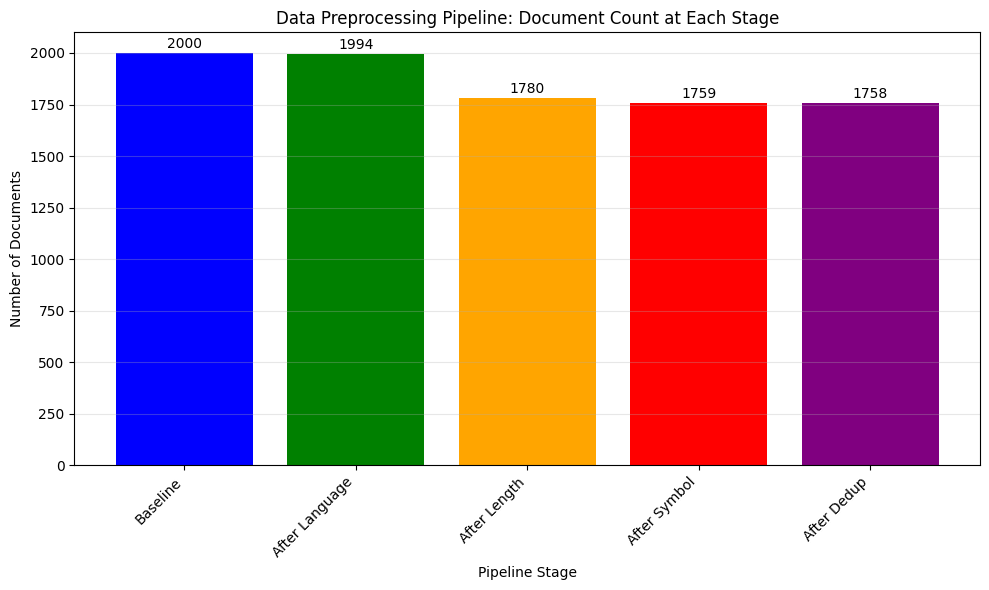

In [16]:
import matplotlib.pyplot as plt

# Create bar chart showing document counts at each stage
stages = ['Baseline', 'After Language', 'After Length', 'After Symbol', 'After Dedup']
counts = [
    baseline["n_docs"],
    pipeline_counts.get("after_language", 0),
    pipeline_counts.get("after_length", 0),
    pipeline_counts.get("after_symbol", 0),
    final["n_docs"]
]

plt.figure(figsize=(10, 6))
plt.bar(stages, counts, color=['blue', 'green', 'orange', 'red', 'purple'])
plt.xlabel('Pipeline Stage')
plt.ylabel('Number of Documents')
plt.title('Data Preprocessing Pipeline: Document Count at Each Stage')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, v in enumerate(counts):
    plt.text(i, v + 10, str(v), ha='center', va='bottom')

plt.show()

